<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_4_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_K_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B8%D1%85_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9%20(%D0%BF%D0%BE%D1%87%D1%82%D0%B8%20%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D1%87).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Метод K-ближайших соседей**

Для всех классификаторов из Sklearn подбирайте лучшие гиперпараметры для модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

# **Базовый алгоритм KNN**

## **KNN для классификации**

### **Получение данных**

Будем работать с набором данным `iris` из `sklearn`.

In [2]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [3]:
# Ваш код здесь
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

#### 1.2. Обучите модель KNN

In [4]:
# Ваш код здесь
p = {'n_neighbors': [3,5,7,9,11,13,15], 'weights': ['uniform','distance'], 'metric': ['euclidean','manhattan']}
knn = KNeighborsClassifier()
gs = GridSearchCV(knn, p, cv=5, scoring='accuracy')
gs.fit(X_tr, y_tr)
print(gs.best_params_)
print(gs.best_score_)

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
0.9583333333333334


#### 1.3. Проверьте качество работы модели

In [5]:
# Ваш код здесь
y_pr = gs.predict(X_te)
print(accuracy_score(y_te, y_pr))

1.0


#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

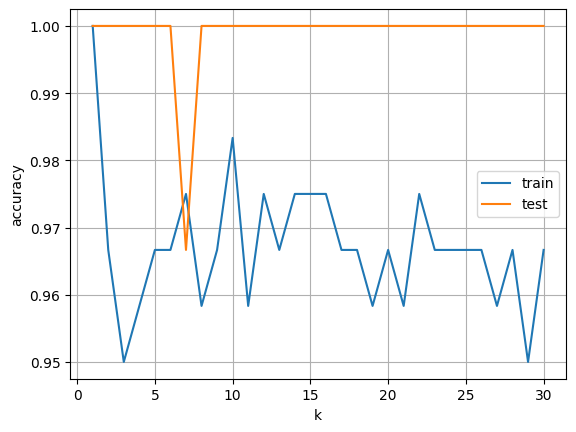

    k     train      test
0   1  1.000000  1.000000
1   2  0.966667  1.000000
2   3  0.950000  1.000000
3   4  0.958333  1.000000
4   5  0.966667  1.000000
5   6  0.966667  1.000000
6   7  0.975000  0.966667
7   8  0.958333  1.000000
8   9  0.966667  1.000000
9  10  0.983333  1.000000
Best: 1


In [6]:
# Ваш код здесь
k_vals = range(1, 31)
tr_acc = []
te_acc = []
for k in k_vals:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_tr, y_tr)
    tr_acc.append(m.score(X_tr, y_tr))
    te_acc.append(m.score(X_te, y_te))

plt.plot(k_vals, tr_acc, label='train')
plt.plot(k_vals, te_acc, label='test')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.legend()
plt.grid()
plt.show()

res = pd.DataFrame({'k': k_vals, 'train': tr_acc, 'test': te_acc})
print(res.head(10))

best_k = k_vals[np.argmax(te_acc)]
print(f"Best: {best_k}")

### **2. KNN рукописный**

#### 2.1. Возьмите два случайных тестовых объектов

In [7]:
# Ваш код здесь
import random
idx = random.sample(range(len(X_te)), 2)
x1 = X_te.iloc[idx[0]]
x2 = X_te.iloc[idx[1]]
y1 = y_te[idx[0]]
y2 = y_te[idx[1]]

k = best_k

#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [8]:
# Ваш код здесь
import numpy as np

def pred(x, X_tr, y_tr, k):
    X_arr = X_tr.values if hasattr(X_tr, 'values') else X_tr
    d = np.sqrt(((X_arr - x.values) ** 2).sum(axis=1))
    nb = np.argsort(d)[:k]
    labels = y_tr[nb]
    pred_class = np.bincount(labels).argmax()
    return pred_class, d[nb], nb

#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [9]:
# Ваш код здесь
p1, d1, n1 = pred(x1, X_tr, y_tr, k)
p2, d2, n2 = pred(x2, X_tr, y_tr, k)

#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [10]:
# Ваш код здесь
print("Predict obj 1:", p1)
print("Predict obh 2:", p2)

Predict obj 1: 2
Predict obh 2: 0


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [11]:
# Ваш код здесь
print("Obj 1:")
print(f"  Real: {y1}, predict: {p1}")
print(f"  Dist to {k} neibs: {d1}")
print(f"  Neib idx: {n1}\n")

print("Obj 2:")
print(f"  Real: {y2}, predict: {p2}")
print(f"  Dist to {k} neibs: {d2}")
print(f"  Neib idx: {n2}")

Obj 1:
  Real: 2, predict: 2
  Dist to 1 neibs: [0.36055513]
  Neib idx: [85]

Obj 2:
  Real: 0, predict: 0
  Dist to 1 neibs: [0.14142136]
  Neib idx: [55]


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [12]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### **KNN из sklearn**

#### 3.1. Разбейте данные на обучение и тест

In [13]:
# Ваш код здесь
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

Затем нормализуйте данные:

In [14]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_tr)

X_tr = pd.DataFrame(mms.transform(X_tr), columns=X_tr.columns)
X_te = pd.DataFrame(mms.transform(X_te), columns=X_te.columns)

#### 3.2. Обучите модель KNN


In [15]:
# Ваш код здесь
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

p = {'n_neighbors': [3,5,7,9,11,13,15], 'weights': ['uniform','distance'], 'metric': ['euclidean','manhattan']}

knn_r = KNeighborsRegressor()
gs = GridSearchCV(knn_r, p, cv=5, scoring='neg_mean_squared_error')
gs.fit(X_tr, y_tr)

print(gs.best_params_)
print(gs.best_score_)

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
-0.35224122141276765


#### 3.3. Проверьте качество работы модели

In [16]:
# Ваш код здесь
from sklearn.metrics import mean_squared_error, r2_score

y_pr = gs.predict(X_te)
mse = mean_squared_error(y_te, y_pr)
r2 = r2_score(y_te, y_pr)

print("MSE test:", mse)
print("R2 test:", r2)

MSE test: 0.3576639293963646
R2 test: 0.7270593109973233


#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

    k       MSE        R2
0   1  0.612007  0.532965
1   2  0.468504  0.642475
2   3  0.432750  0.669759
3   4  0.416986  0.681789
4   5  0.406943  0.689453
5   6  0.400342  0.694491
6   7  0.396266  0.697602
7   8  0.393668  0.699584
8   9  0.397196  0.696891
9  10  0.395680  0.698048


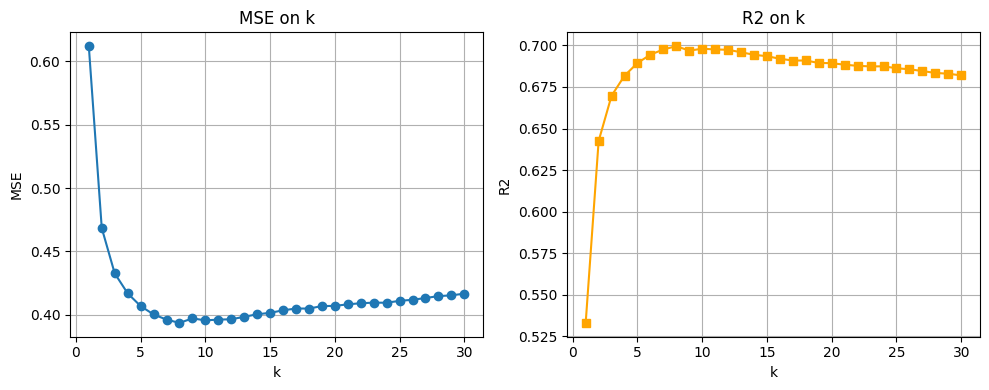

Best k min MSE: 8
Best k max R2: 8


In [17]:
# Ваш код здесь
k_vals = range(1, 31)
mse_vals = []
r2_vals = []

for k in k_vals:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_tr, y_tr)
    y_pr_k = m.predict(X_te)
    mse_vals.append(mean_squared_error(y_te, y_pr_k))
    r2_vals.append(r2_score(y_te, y_pr_k))

res = pd.DataFrame({'k': k_vals, 'MSE': mse_vals, 'R2': r2_vals})
print(res.head(10))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(k_vals, mse_vals, marker='o')
plt.xlabel('k')
plt.ylabel('MSE')
plt.title('MSE on k')
plt.grid()

plt.subplot(1,2,2)
plt.plot(k_vals, r2_vals, marker='s', color='orange')
plt.xlabel('k')
plt.ylabel('R2')
plt.title('R2 on k')
plt.grid()
plt.tight_layout()
plt.show()

best_k_mse = k_vals[np.argmin(mse_vals)]
best_k_r2 = k_vals[np.argmax(r2_vals)]
print(f"Best k min MSE: {best_k_mse}")
print(f"Best k max R2: {best_k_r2}")

### **4. KNN рукописный**

#### 4.1. Возьмите два случайных тестовых объектов

In [18]:
# Ваш код здесь
k = gs.best_params_['n_neighbors']

idx = random.sample(range(len(X_te)), 2)
x1 = X_te.iloc[idx[0]]
x2 = X_te.iloc[idx[1]]
y1 = y_te[idx[0]]
y2 = y_te[idx[1]]

#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [19]:
# Ваш код здесь
def pred_reg(x, X_tr, y_tr, k):
    X_arr = X_tr.values if hasattr(X_tr, 'values') else X_tr
    d = np.sqrt(((X_arr - x.values) ** 2).sum(axis=1))
    nb = np.argsort(d)[:k]
    pred_val = np.mean(y_tr[nb])
    return pred_val, d[nb], nb

#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [20]:
# Ваш код здесь
p1, d1, n1 = pred_reg(x1, X_tr, y_tr, k)
p2, d2, n2 = pred_reg(x2, X_tr, y_tr, k)

#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [21]:
# Ваш код здесь
print("Predict obj 1: {:.4f}".format(p1))
print("Predict obj 2: {:.4f}".format(p2))

Predict obj 1: 1.3398
Predict obj 2: 0.9744


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [22]:
# Ваш код здесь
print("Obj 1:")
print(f"  Real: {y1:.4f}, predict: {p1:.4f}")
print(f"  Dist to {k} neibs: {np.round(d1, 4)}")
print(f"  Neib idx: {n1}\n")

print("Obj 2:")
print(f"  Real: {y2:.4f}, predict: {p2:.4f}")
print(f"  Dist to {k} neibs: {np.round(d2, 4)}")
print(f"  Neib idx: {n2}")

Obj 1:
  Real: 1.4750, predict: 1.3398
  Dist to 11 neibs: [0.03   0.0308 0.0316 0.0322 0.0334 0.0371 0.0399 0.04   0.0402 0.044
 0.046 ]
  Neib idx: [ 7910 12496  7901 11844  1053  9400 14414 13141   365 12139 11980]

Obj 2:
  Real: 0.5800, predict: 0.9744
  Dist to 11 neibs: [0.0263 0.0274 0.0296 0.0303 0.0319 0.0342 0.0395 0.0416 0.0515 0.052
 0.055 ]
  Neib idx: [13647  4420  7286   610 13742  4158 14621  2240 10054   635   937]


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# **Weighted KNN**

## **KNN для классификации**

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [23]:
from sklearn.datasets import load_iris
import pandas as pd


d = load_iris()

X = pd.DataFrame(d['data'], columns=d['feature_names'])
y = d['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [24]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [25]:
# Ваш код здесь
X_sel = X.iloc[:, [0, 3]]
X_sel.columns = ['sepal_len', 'petal_wid']

### Визуализируйте ваши данные на графике

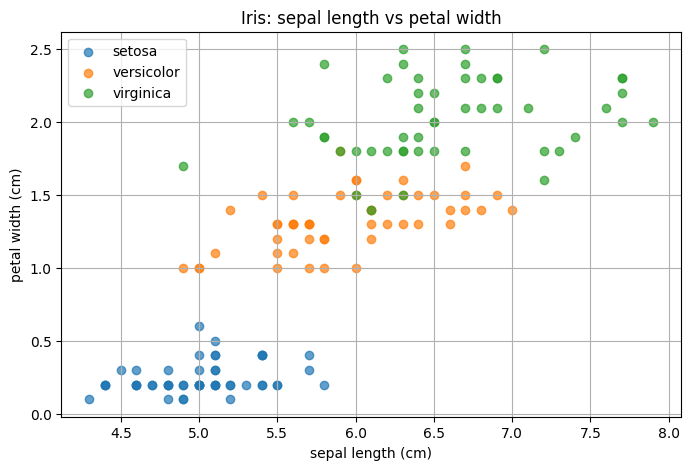

In [26]:
# Ваш код здесь
plt.figure(figsize=(8, 5))
for c in [0, 1, 2]:
    plt.scatter(X_sel[y==c]['sepal_len'], X_sel[y==c]['petal_wid'],
                label=d.target_names[c], alpha=0.7)
plt.xlabel('sepal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Iris: sepal length vs petal width')
plt.legend()
plt.grid(True)
plt.show()

### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [27]:
# Ваш код здесь
X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.2, random_state=42)

#### 1.2. Обучите модель KNN на 50 соседях

In [28]:
# Ваш код здесь
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_tr, y_tr)

KNeighborsClassifier(n_neighbors=50)

#### 1.3. Проверьте качество работы модели

In [29]:
# Ваш код здесь
y_pr = knn.predict(X_te)
acc = accuracy_score(y_te, y_pr)
print(f"{acc:.4f}")

0.9333


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [30]:
# Ваш код здесь
idx = random.randint(0, len(X_te)-1)
x_test = X_te.iloc[idx]
y_true = y_te[idx]

X_tr_arr = X_tr.values
dists = np.sqrt(((X_tr_arr - x_test.values) ** 2).sum(axis=1))

print(f"Test obj {idx}, real: {y_true}")
print(f"Dist to 5 learn obj: {dists[:5]}")
print(f"Min dist: {dists.min():.4f}, max: {dists.max():.4f}")

Test obj 4, real: 1
Dist to 5 learn obj: [2.50599282 1.48660687 0.1        2.33238076 2.68328157]
Min dist: 0.1000, max: 2.8178


#### 1.5. Выберите топ  k  соседей


In [31]:
# Ваш код здесь
k = 5

dists = np.sqrt(((X_tr.values - x_test.values) ** 2).sum(axis=1))
nb_idx = np.argsort(dists)[:k]
nb_dists = dists[nb_idx]
nb_labels = y_tr[nb_idx]

#### 1.6. Выведите финальное предсказание для этого объекта

In [32]:
# Ваш код здесь
from collections import Counter
pred_manual = Counter(nb_labels).most_common(1)[0][0]

print(f"{pred_manual}")

1


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [33]:
# Ваш код здесь
print(f"Real: {y_true}")

pred_sklearn = knn.predict([x_test])[0]
print(f"Predict sklearn (k=50): {pred_sklearn}")

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_tr, y_tr)
pred_sklearn5 = knn5.predict([x_test])[0]
print(f"Predict sklearn (k=5): {pred_sklearn5}")

Real: 1
Predict sklearn (k=50): 2
Predict sklearn (k=5): 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

/tmp/ipykernel_8447/3173239377.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(x_test[0], x_test[1], c='black', marker='X', s=200, edgecolors='white', linewidths=2, label='Test object')


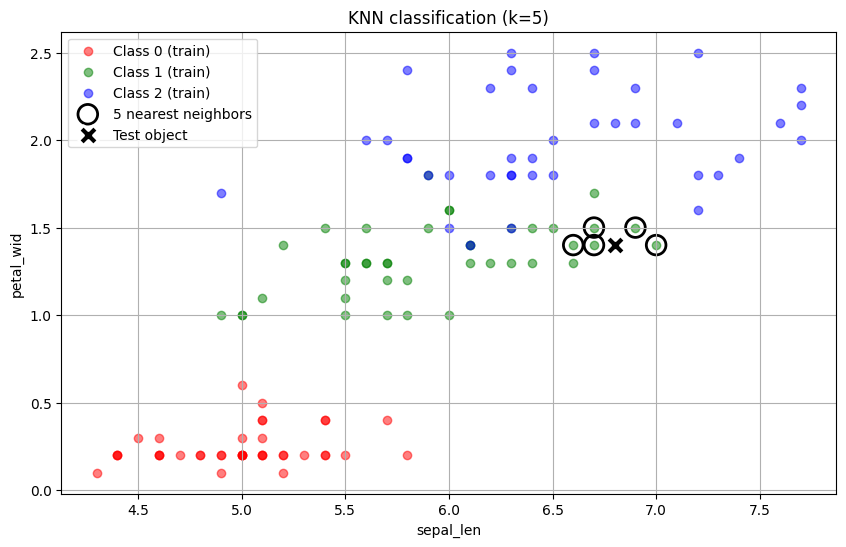

In [34]:
# Ваш код здесь
colors = {0: 'red', 1: 'green', 2: 'blue'}

plt.figure(figsize=(10, 6))

for c in [0, 1, 2]:
    mask = y_tr == c
    plt.scatter(X_tr.loc[mask, X_tr.columns[0]], X_tr.loc[mask, X_tr.columns[1]], c=colors[c], label=f'Class {c} (train)', alpha=0.5)

plt.scatter(X_tr.iloc[nb_idx, 0], X_tr.iloc[nb_idx, 1], s=200, facecolors='none', edgecolors='black', linewidths=2, label=f'{k} nearest neighbors')
plt.scatter(x_test[0], x_test[1], c='black', marker='X', s=200, edgecolors='white', linewidths=2, label='Test object')

plt.xlabel(X_tr.columns[0])
plt.ylabel(X_tr.columns[1])
plt.title(f'KNN classification (k={k})')
plt.legend()
plt.grid(True)
plt.show()

### **2. Weighted KNN**

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [35]:
# Ваш код здесь
knn_w = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_w.fit(X_tr, y_tr)

KNeighborsClassifier(weights='distance')

#### 2.2. Проверьте качество работы модели


In [67]:
# Ваш код здесь
y_pr_w = knn_w.predict(X_te)
acc_w = accuracy_score(y_te, y_pr_w)
print(f"{acc_w:.4f}")

0.9333


#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [68]:
# Ваш код здесь
try:
    x_test
except NameError:
    import random
    idx = random.randint(0, len(X_te)-1)
    x_test = X_te.iloc[idx]
    y_true = y_te[idx]

X_tr_arr = X_tr.values
x_test_arr = x_test.values
dists = np.sqrt(((X_tr_arr - x_test_arr) ** 2).sum(axis=1))

print(f"{y_true}")

1


#### 2.4. Выберите топ  k  соседей


In [71]:
# Ваш код здесь
nb_idx = np.argsort(dists)[:k]
nb_dists = dists[nb_idx]
nb_labels = y_tr[nb_idx]

print(nb_idx)
print(nb_dists)
print(nb_labels)

[  2  12 105  18  82]
[0.1        0.14142136 0.14142136 0.2        0.2       ]
[1 1 1 1 1]


#### 2.5. Рассчитайте вес для каждого соседа

In [72]:
# Ваш код здесь
eps = 1e-8
w = 1 / (nb_dists + eps)
print(w)

[9.999999   7.07106731 7.07106731 4.99999975 4.99999975]


#### 2.6. Выведите финальное предсказание для этого объекта

In [73]:
# Ваш код здесь
votes = {}
for lab, wei in zip(nb_labels, w):
    votes[lab] = votes.get(lab, 0) + wei
pred_man = max(votes, key=votes.get)
print(f"{pred_man}")

1


#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [74]:
# Ваш код здесь
pred_sk = knn_w.predict(pd.DataFrame([x_test]))[0]
print(f"Real: {y_true}")
print(f"Predict sklearn: {pred_sk}")
print(f"Predict: {pred_man}")


Real: 1
Predict sklearn: 1
Predict: 1


In [42]:
# Ваш код здесь


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

/tmp/ipykernel_8447/1153344248.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(x_test[0], x_test[1], c='red', marker='X', s=100, edgecolors='black', linewidths=2, label='Test object')


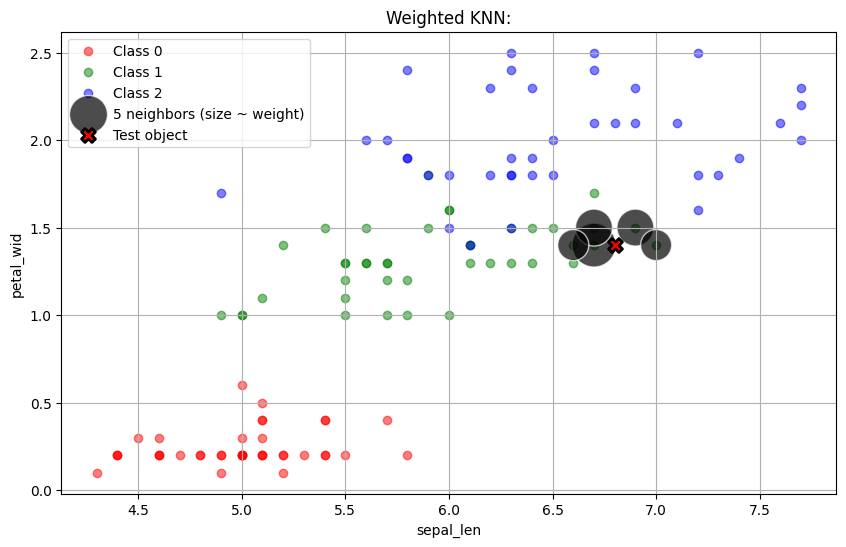

In [77]:
# Ваш код здесь
colors = {0: 'red', 1: 'green', 2: 'blue'}

plt.figure(figsize=(10, 6))

for c in [0, 1, 2]:
    mask = y_tr == c
    plt.scatter(X_tr.loc[mask, X_tr.columns[0]], X_tr.loc[mask, X_tr.columns[1]], c=colors[c], label=f'Class {c}', alpha=0.5)

sizes = w * 100
plt.scatter(X_tr.iloc[nb_idx, 0], X_tr.iloc[nb_idx, 1], s=sizes, c='black', alpha=0.7, edgecolors='white', linewidths=1,label=f'{k} neighbors (size ~ weight)')

plt.scatter(x_test[0], x_test[1], c='red', marker='X', s=100, edgecolors='black', linewidths=2, label='Test object')

plt.xlabel(X_tr.columns[0])
plt.ylabel(X_tr.columns[1])
plt.title('Weighted KNN:')
plt.legend()
plt.grid(True)
plt.show()

## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [78]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


d = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [45]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [79]:
# Ваш код здесь
X_small = X[['MedInc']].iloc[:1000]
y_small = y[:1000]

print(X_small.shape)
print(y_small.shape)

(1000, 1)
(1000,)


### Отрисуйте данные на графике

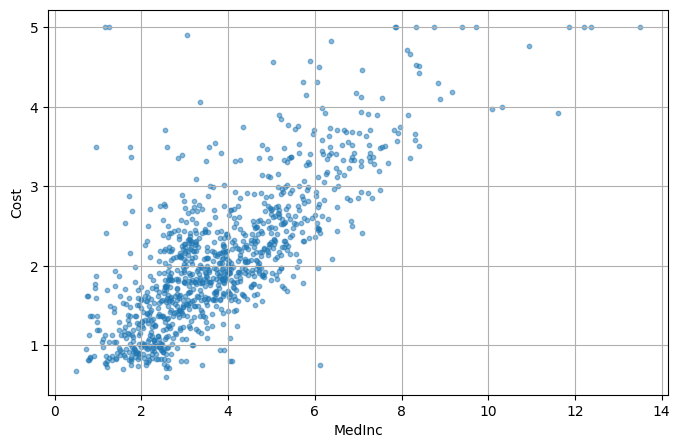

In [80]:
# Ваш код здесь
plt.figure(figsize=(8, 5))
plt.scatter(X_small, y_small, alpha=0.5, s=10)
plt.xlabel('MedInc')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

### **4. KNN из sklearn**

#### 4.1. Разбейте данные на обучение и тест

In [81]:
# Ваш код здесь
X_tr, X_te, y_tr, y_te = train_test_split(X_small, y_small, test_size=0.2, random_state=42)

#### 4.2. Обучите модель KNN на 100 соседях


In [82]:
# Ваш код здесь
knn_r = KNeighborsRegressor(n_neighbors=100)
knn_r.fit(X_tr, y_tr)

KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели


In [83]:
# Ваш код здесь
y_pr = knn_r.predict(X_te)
mse = mean_squared_error(y_te, y_pr)
r2 = r2_score(y_te, y_pr)

print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")

MSE: 0.2540
R2: 0.6507


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [84]:
# Ваш код здесь
idx = random.randint(0, len(X_te)-1)
x_test = X_te.iloc[idx]
y_true = y_te[idx]

print(f"Test obj: MedInc = {x_test.values[0]:.4f}, real cost = {y_true:.4f}")

dists = np.abs(X_tr.values - x_test.values).flatten()
print(dists[:5])

Test obj: MedInc = 3.3958, real cost = 1.4190
[1.7083 1.8643 0.9752 1.7081 0.9917]


#### 4.5. Выберите топ  k  соседей


In [52]:
# Ваш код здесь


#### 4.6. Выведите финальное предсказание для этого объекта

In [53]:
# Ваш код здесь


#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [54]:
# Ваш код здесь


In [55]:
# Ваш код здесь


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

In [56]:
# Ваш код здесь


### **5. Weighted KNN**

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [57]:
# Ваш код здесь


#### 5.2. Проверьте качество работы модели


In [58]:
# Ваш код здесь


#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [59]:
# Ваш код здесь


#### 5.4. Выберите топ  k  соседей


In [60]:
# Ваш код здесь


#### 5.5. Рассчитайте вес для каждого соседа

In [61]:
# Ваш код здесь


#### 5.6. Выведите финальное предсказание для этого объекта

In [62]:
# Ваш код здесь


#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [63]:
# Ваш код здесь


In [64]:
# Ваш код здесь


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

In [65]:
# Ваш код здесь


## 6. Подберите лучшие гиперпараметры для последней модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [66]:
# Ваш код здесь